In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import math
from pathlib import Path

import numpy as np

import dev
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from richio.plots import scalar_map

REPO = Path("/home/hey4/rich_tde")
SHOCK_ROOT = REPO / "data/processed/ShockFinderEdissSelection/analysis/zoom-shocks"
OUTPUT_ROOT = SHOCK_ROOT / "presentation/self-intersection"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SNAPSHOTS = {"1e4": 77, "1e5": 142, "1e6": 850}
SELF_INTERSECTION_PRESENT = {"1e4": True, "1e5": False, "1e6": True}
DENSITY_DECADES = 6
DISSIPATION_DECADES = 2
DENSITY_CMAP = "twilight"
MACH_THRESHOLDS = (2.0, 7.0, 15.0, 25.0)
MACH_LABELS = ("<2", "2–7", "7–15", "15–25", "≥25")
MACH_COLORS = ("#0072B2", "#009E73", "#F0E442", "#E69F00", "#D55E00")
MACH_CMAP = ListedColormap(MACH_COLORS)
MACH_NORM = BoundaryNorm(np.arange(-0.5, 5.5), MACH_CMAP.N)
EMPTY_SHOCK_COLOR = "0.65"
DISSIPATION_CMAP = "viridis"
FIGSIZE = (12.0, 3.4)
DPI = 240
SELF_STREAMLINES = {"color": "white", "density": 0.8, "linewidth": 0.5, "arrowsize": 0.7}


In [2]:
def logged_limits(logged_values, decades):
    finite = logged_values[np.isfinite(logged_values)]
    data_min = float(np.min(finite))
    data_max = float(np.max(finite))
    if data_max - data_min < 3:
        return data_min, data_max
    vmin = math.floor(2 * data_min) / 2
    vmax = math.ceil(2 * data_max) / 2
    return max(vmin, vmax - decades), vmax


def compact_colorbar(fig, ax, image, label):
    cax = inset_axes(
        ax,
        width="100%",
        height="6%",
        loc="lower left",
        bbox_to_anchor=(0.0, 1.085, 1.0, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    bar = fig.colorbar(image, cax=cax, orientation="horizontal")
    bar.set_label(label, fontsize=10, labelpad=4, color="black")
    bar.outline.set_edgecolor("black")
    cax.tick_params(which="both", labelsize=9, length=2, pad=1, colors="black")
    cax.xaxis.set_label_position("top")
    if label == r"$\mathcal{M}$":
        bar.set_ticks(np.arange(len(MACH_LABELS)))
        bar.set_ticklabels(MACH_LABELS)


def mach_categories(values):
    empty = ~np.isfinite(values) | (values <= 0)
    categories = np.digitize(np.nan_to_num(values), MACH_THRESHOLDS)
    return np.ma.array(categories, mask=empty)


1e4 M_sun | snap 77 | t/t_fb=0.9990 | self-intersection | center/r_p=(-10.583, 4.015, -0.003) | slab shock cells with M_P >= 1.5: 85 | max-bin grid=(256, 128) | Mach pixels: ANN=1,228, max-bin=71 | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/self-intersection/self_intersection_shocks_maxbin_1e4_snap_0077.png


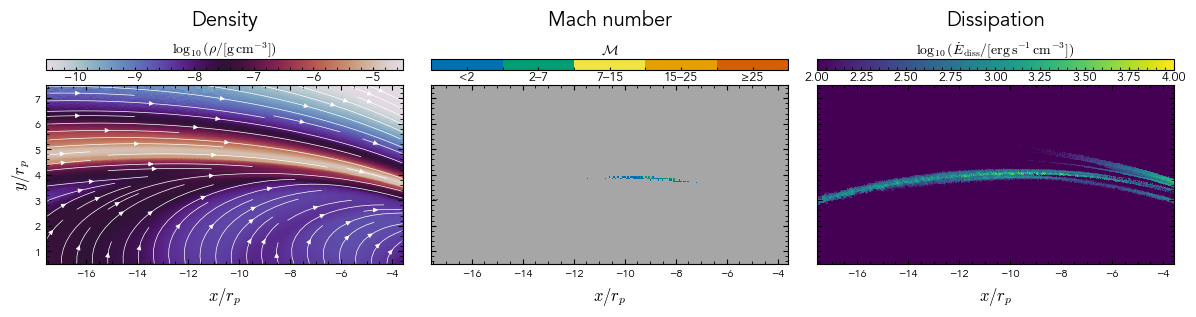

In [3]:
run = "1e4"
snapnum = SNAPSHOTS[run]
field_path = SHOCK_ROOT / "self-intersection" / run / f"self_intersection_snap_{snapnum:04d}.npz"
ann_mach_path = SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
mach_path = SHOCK_ROOT / "self-mach-max" / run / f"self_mach_max_snap_{snapnum:04d}.npz"

with np.load(field_path) as data:
    x_rp = np.array(data["x_rp"])
    y_rp = np.array(data["y_rp"])
    density = np.array(data["density"])
    dissipation = np.array(data["dissipation"])
    vx = np.array(data["vx_kms"])
    vy = np.array(data["vy_kms"])
    center_rp = np.array(data["center_rp"])
    half_width_rp = np.array(data["half_width_rp"])
with np.load(ann_mach_path) as data:
    ann_mach = np.array(data["self_mach_P"])
with np.load(mach_path) as data:
    mach_x_rp = np.array(data["x_rp"])
    mach_y_rp = np.array(data["y_rp"])
    mach = np.array(data["mach_P_max"])
    mach_min = float(data["mach_min"])
    slab_shock_cells = int(data["slab_cell_count"])
with np.load(
    SHOCK_ROOT.parent.parent / run / f"shockfinder_snap_{snapnum:04d}.npz"
) as data:
    time_tfb = float(data["time_tfb"])

xlim = (center_rp[0] - half_width_rp[0], center_rp[0] + half_width_rp[0])
ylim = (center_rp[1] - half_width_rp[1], center_rp[1] + half_width_rp[1])
fields = (
    (
        density,
        "Density",
        r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        DENSITY_CMAP,
        logged_limits(density, DENSITY_DECADES),
    ),
    (mach, "Mach number", r"$\mathcal{M}$", MACH_CMAP, None),
    (
        dissipation,
        "Dissipation",
        r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        DISSIPATION_CMAP,
        logged_limits(dissipation, DISSIPATION_DECADES),
    ),
)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, gridspec_kw={"wspace": 0.08})
for column, (grid, title, label, cmap_name, limits) in enumerate(fields):
    plot_cmap = plt.get_cmap(cmap_name).copy()
    if column == 1:
        grid = mach_categories(grid)
    else:
        plot_cmap.set_bad(plot_cmap(0.0))
    plot_x, plot_y = (mach_x_rp, mach_y_rp) if column == 1 else (x_rp, y_rp)
    _, image = scalar_map(
        grid,
        plot_x,
        plot_y,
        ax=axes[column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if column == 1
            else {"vmin": limits[0], "vmax": limits[1]}
        ),
        shading="auto",
        rasterized=True,
    )
    image.colorbar.remove()
    if column == 1:
        image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        image.changed()
    compact_colorbar(fig, axes[column], image, label)
    axes[column].set_title(title, pad=43)
    axes[column].set_box_aspect(0.5)
    axes[column].set_xlim(xlim)
    axes[column].set_ylim(ylim)
    axes[column].set_xlabel(r"$x/r_p$")
    axes[column].tick_params(labelsize=8)

axes[0].streamplot(x_rp, y_rp, vx.T, vy.T, **SELF_STREAMLINES)
axes[0].set_ylabel(r"$y/r_p$", labelpad=2)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.16, top=0.72)
output = OUTPUT_ROOT / f"self_intersection_shocks_maxbin_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
status = "self-intersection" if SELF_INTERSECTION_PRESENT[run] else "no self-intersection yet"
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | {status} | "
    f"center/r_p={tuple(np.round(center_rp, 3).tolist())} | "
    f"slab shock cells with M_P >= {mach_min:g}: {slab_shock_cells:,} | "f"max-bin grid={mach.shape} | Mach pixels: "f"ANN={np.count_nonzero(ann_mach):,}, max-bin={np.count_nonzero(mach):,} | {output}"
)
plt.show()


1e5 M_sun | snap 142 | t/t_fb=0.4975 | no self-intersection yet | center/r_p=(-70.102, -3.145, -0.0) | slab shock cells with M_P >= 1.5: 2,182 | max-bin grid=(256, 128) | Mach pixels: ANN=2,116, max-bin=455 | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/self-intersection/self_intersection_shocks_maxbin_1e5_snap_0142.png


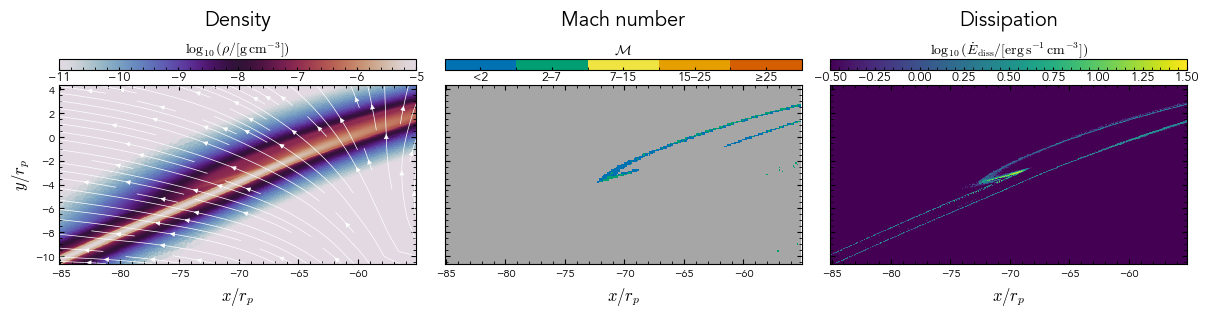

In [4]:
run = "1e5"
snapnum = SNAPSHOTS[run]
field_path = SHOCK_ROOT / "self-intersection" / run / f"self_intersection_snap_{snapnum:04d}.npz"
ann_mach_path = SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
mach_path = SHOCK_ROOT / "self-mach-max" / run / f"self_mach_max_snap_{snapnum:04d}.npz"

with np.load(field_path) as data:
    x_rp = np.array(data["x_rp"])
    y_rp = np.array(data["y_rp"])
    density = np.array(data["density"])
    dissipation = np.array(data["dissipation"])
    vx = np.array(data["vx_kms"])
    vy = np.array(data["vy_kms"])
    center_rp = np.array(data["center_rp"])
    half_width_rp = np.array(data["half_width_rp"])
with np.load(ann_mach_path) as data:
    ann_mach = np.array(data["self_mach_P"])
with np.load(mach_path) as data:
    mach_x_rp = np.array(data["x_rp"])
    mach_y_rp = np.array(data["y_rp"])
    mach = np.array(data["mach_P_max"])
    mach_min = float(data["mach_min"])
    slab_shock_cells = int(data["slab_cell_count"])
with np.load(
    SHOCK_ROOT.parent.parent / run / f"shockfinder_snap_{snapnum:04d}.npz"
) as data:
    time_tfb = float(data["time_tfb"])

xlim = (center_rp[0] - half_width_rp[0], center_rp[0] + half_width_rp[0])
ylim = (center_rp[1] - half_width_rp[1], center_rp[1] + half_width_rp[1])
fields = (
    (
        density,
        "Density",
        r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        DENSITY_CMAP,
        logged_limits(density, DENSITY_DECADES),
    ),
    (mach, "Mach number", r"$\mathcal{M}$", MACH_CMAP, None),
    (
        dissipation,
        "Dissipation",
        r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        DISSIPATION_CMAP,
        logged_limits(dissipation, DISSIPATION_DECADES),
    ),
)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, gridspec_kw={"wspace": 0.08})
for column, (grid, title, label, cmap_name, limits) in enumerate(fields):
    plot_cmap = plt.get_cmap(cmap_name).copy()
    if column == 1:
        grid = mach_categories(grid)
    else:
        plot_cmap.set_bad(plot_cmap(0.0))
    plot_x, plot_y = (mach_x_rp, mach_y_rp) if column == 1 else (x_rp, y_rp)
    _, image = scalar_map(
        grid,
        plot_x,
        plot_y,
        ax=axes[column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if column == 1
            else {"vmin": limits[0], "vmax": limits[1]}
        ),
        shading="auto",
        rasterized=True,
    )
    image.colorbar.remove()
    if column == 1:
        image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        image.changed()
    compact_colorbar(fig, axes[column], image, label)
    axes[column].set_title(title, pad=43)
    axes[column].set_box_aspect(0.5)
    axes[column].set_xlim(xlim)
    axes[column].set_ylim(ylim)
    axes[column].set_xlabel(r"$x/r_p$")
    axes[column].tick_params(labelsize=8)

axes[0].streamplot(x_rp, y_rp, vx.T, vy.T, **SELF_STREAMLINES)
axes[0].set_ylabel(r"$y/r_p$", labelpad=2)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.16, top=0.72)
output = OUTPUT_ROOT / f"self_intersection_shocks_maxbin_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
status = "self-intersection" if SELF_INTERSECTION_PRESENT[run] else "no self-intersection yet"
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | {status} | "
    f"center/r_p={tuple(np.round(center_rp, 3).tolist())} | "
    f"slab shock cells with M_P >= {mach_min:g}: {slab_shock_cells:,} | "f"max-bin grid={mach.shape} | Mach pixels: "f"ANN={np.count_nonzero(ann_mach):,}, max-bin={np.count_nonzero(mach):,} | {output}"
)
plt.show()


1e6 M_sun | snap 850 | t/t_fb=1.0015 | self-intersection | center/r_p=(-81.045, 12.495, -0.015) | slab shock cells with M_P >= 1.5: 2,020 | max-bin grid=(256, 128) | Mach pixels: ANN=1,757, max-bin=262 | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/self-intersection/self_intersection_shocks_maxbin_1e6_snap_0850.png


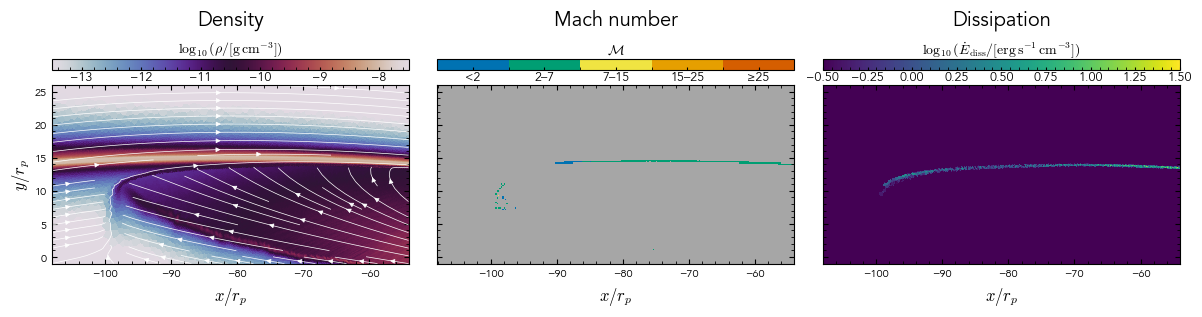

In [5]:
run = "1e6"
snapnum = SNAPSHOTS[run]
field_path = SHOCK_ROOT / "self-intersection" / run / f"self_intersection_snap_{snapnum:04d}.npz"
ann_mach_path = SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
mach_path = SHOCK_ROOT / "self-mach-max" / run / f"self_mach_max_snap_{snapnum:04d}.npz"

with np.load(field_path) as data:
    x_rp = np.array(data["x_rp"])
    y_rp = np.array(data["y_rp"])
    density = np.array(data["density"])
    dissipation = np.array(data["dissipation"])
    vx = np.array(data["vx_kms"])
    vy = np.array(data["vy_kms"])
    center_rp = np.array(data["center_rp"])
    half_width_rp = np.array(data["half_width_rp"])
with np.load(ann_mach_path) as data:
    ann_mach = np.array(data["self_mach_P"])
with np.load(mach_path) as data:
    mach_x_rp = np.array(data["x_rp"])
    mach_y_rp = np.array(data["y_rp"])
    mach = np.array(data["mach_P_max"])
    mach_min = float(data["mach_min"])
    slab_shock_cells = int(data["slab_cell_count"])
with np.load(
    SHOCK_ROOT.parent.parent / run / f"shockfinder_snap_{snapnum:04d}.npz"
) as data:
    time_tfb = float(data["time_tfb"])

xlim = (center_rp[0] - half_width_rp[0], center_rp[0] + half_width_rp[0])
ylim = (center_rp[1] - half_width_rp[1], center_rp[1] + half_width_rp[1])
fields = (
    (
        density,
        "Density",
        r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        DENSITY_CMAP,
        logged_limits(density, DENSITY_DECADES),
    ),
    (mach, "Mach number", r"$\mathcal{M}$", MACH_CMAP, None),
    (
        dissipation,
        "Dissipation",
        r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        DISSIPATION_CMAP,
        logged_limits(dissipation, DISSIPATION_DECADES),
    ),
)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, gridspec_kw={"wspace": 0.08})
for column, (grid, title, label, cmap_name, limits) in enumerate(fields):
    plot_cmap = plt.get_cmap(cmap_name).copy()
    if column == 1:
        grid = mach_categories(grid)
    else:
        plot_cmap.set_bad(plot_cmap(0.0))
    plot_x, plot_y = (mach_x_rp, mach_y_rp) if column == 1 else (x_rp, y_rp)
    _, image = scalar_map(
        grid,
        plot_x,
        plot_y,
        ax=axes[column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if column == 1
            else {"vmin": limits[0], "vmax": limits[1]}
        ),
        shading="auto",
        rasterized=True,
    )
    image.colorbar.remove()
    if column == 1:
        image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        image.changed()
    compact_colorbar(fig, axes[column], image, label)
    axes[column].set_title(title, pad=43)
    axes[column].set_box_aspect(0.5)
    axes[column].set_xlim(xlim)
    axes[column].set_ylim(ylim)
    axes[column].set_xlabel(r"$x/r_p$")
    axes[column].tick_params(labelsize=8)

axes[0].streamplot(x_rp, y_rp, vx.T, vy.T, **SELF_STREAMLINES)
axes[0].set_ylabel(r"$y/r_p$", labelpad=2)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.16, top=0.72)
output = OUTPUT_ROOT / f"self_intersection_shocks_maxbin_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
status = "self-intersection" if SELF_INTERSECTION_PRESENT[run] else "no self-intersection yet"
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | {status} | "
    f"center/r_p={tuple(np.round(center_rp, 3).tolist())} | "
    f"slab shock cells with M_P >= {mach_min:g}: {slab_shock_cells:,} | "f"max-bin grid={mach.shape} | Mach pixels: "f"ANN={np.count_nonzero(ann_mach):,}, max-bin={np.count_nonzero(mach):,} | {output}"
)
plt.show()
